In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Sentiment Analysis
from textblob import TextBlob

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews


In [16]:
import os

dataset_path = "/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews"

for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


In [18]:
import pandas as pd

# Load the Amazon Fine Food Reviews dataset
df = pd.read_csv(
    "/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv"
)

# Display the first 5 rows
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [19]:
print("Dataset Shape:", df.shape)

Dataset Shape: (568454, 10)


In [20]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [23]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [24]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [25]:
# Remove duplicate reviews
df = df.drop_duplicates()

# Remove missing review text
df = df.dropna(subset=['Text'])

# Reset index
df.reset_index(drop=True, inplace=True)

print(df.shape)

(568454, 10)


In [26]:
def sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(sentiment)

df[["Score", "Sentiment"]].head()

,Score,Sentiment
0,5,Positive
1,1,Negative
2,4,Positive
3,2,Negative
4,5,Positive


In [27]:
df['Sentiment'].value_counts()

Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64

In [28]:
(df['Sentiment'].value_counts(normalize=True) * 100).round(2)

Sentiment
Positive    78.07
Negative    14.43
Neutral      7.50
Name: proportion, dtype: float64

In [29]:
df.groupby('Sentiment')['Score'].mean()

Sentiment
Negative    1.362873
Neutral     3.000000
Positive    4.818253
Name: Score, dtype: float64

In [30]:
rating_counts = df['Score'].value_counts().sort_index()

print(rating_counts)

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


/tmp/ipykernel_58/988925428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Score', palette='viridis')


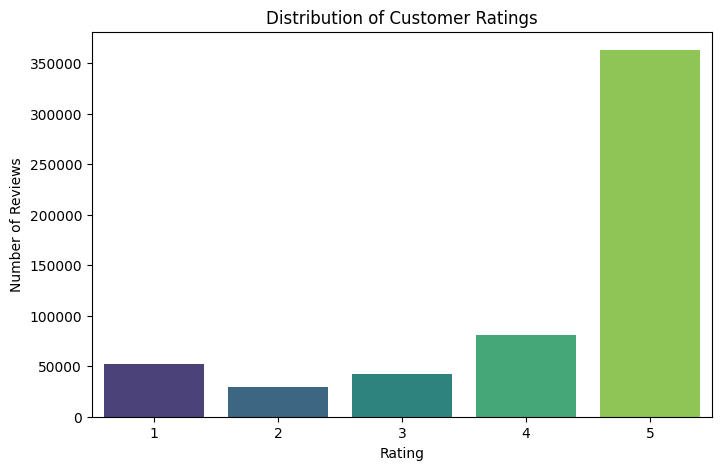

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Score', palette='viridis')

plt.title("Distribution of Customer Ratings")

plt.xlabel("Rating")

plt.ylabel("Number of Reviews")

plt.show()

In [32]:
rating_sentiment = pd.crosstab(df['Score'], df['Sentiment'])

rating_sentiment

Sentiment,Negative,Neutral,Positive
Score,,,
1,52268,0,0
2,29769,0,0
3,0,42640,0
4,0,0,80655
5,0,0,363122


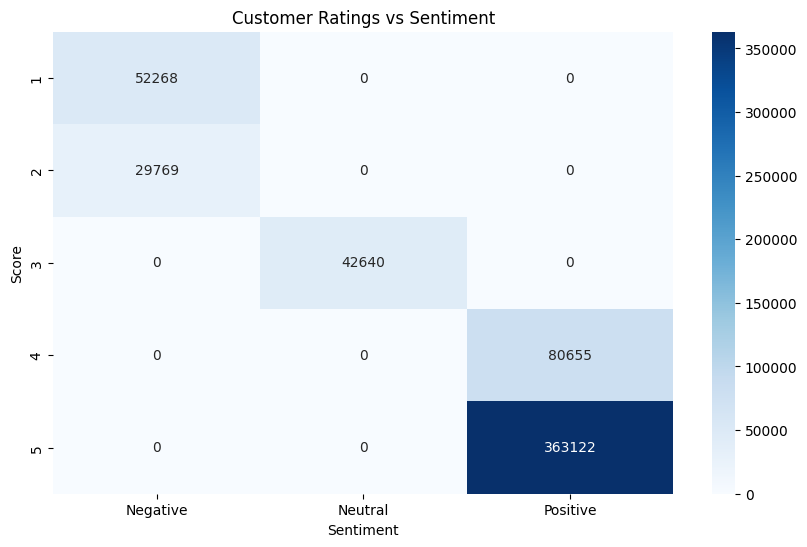

In [33]:
plt.figure(figsize=(10,6))

sns.heatmap(rating_sentiment,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Customer Ratings vs Sentiment")

plt.show()

In [34]:
top_products = df['ProductId'].value_counts().head(10)

print(top_products)

ProductId
B007JFMH8M    913
B002QWHJOU    632
B0026RQTGE    632
B002QWP89S    632
B002QWP8H0    632
B003B3OOPA    623
B001EO5Q64    567
B007M83302    564
B007M832YY    564
B0013NUGDE    564
Name: count, dtype: int64


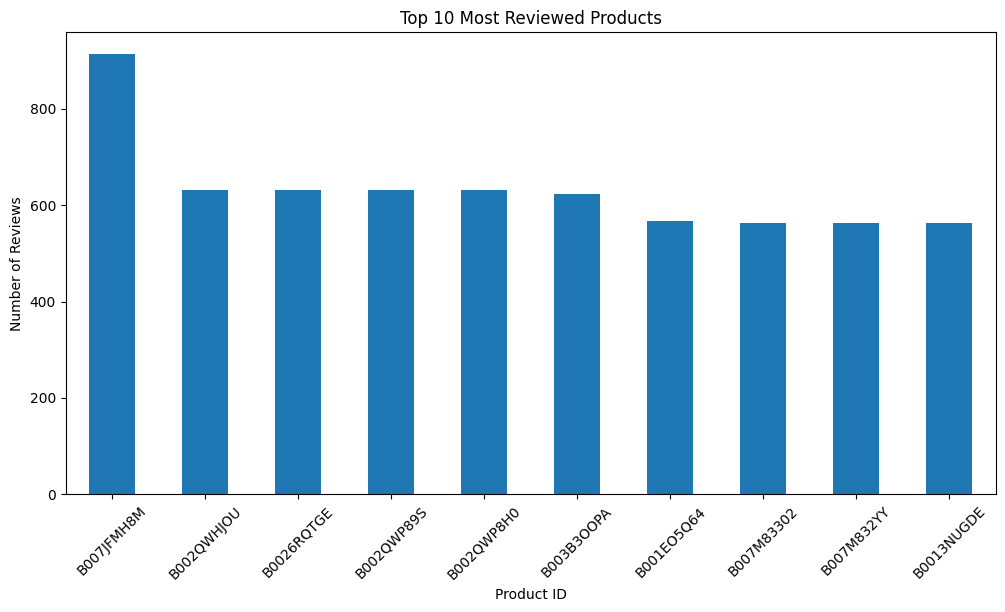

In [35]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Most Reviewed Products")

plt.xlabel("Product ID")

plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

<Axes: xlabel='Sentiment', ylabel='count'>

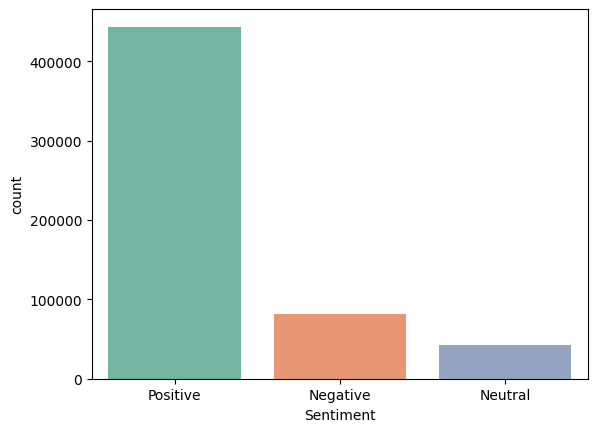

In [37]:
sns.countplot(
    data=df,
    x='Sentiment',
    hue='Sentiment',
    palette='Set2',
    legend=False
)

Business Insights:
Most reviews are positive.
Customers generally rate products 4–5 stars.
Common complaints relate to packaging, freshness, shipping, or quality.
Positive reviews frequently mention taste, value, and product quality.



Recommendations:
Improve packaging for products with frequent complaints.
Monitor products with increasing negative sentiment.
Promote highly rated products.
Use customer feedback to prioritize product improvements.
Track sentiment trends to evaluate future changes.

SYNTECXHUB INTERNSHIP PROJECT 4 ON "Amazon Customers Sentiment Analysis" completeed by OZOJI CORNELIUS OGECHUKWU